# Quantum Capacitance

This notebook walks through the new `compute_quantum_capacitance`
and `fit_quantum_capacitance` methods on the `QPD` class. It mirrors
the step-by-step style of `qpd.ipynb`: derive the quantity from the
Hamiltonian, plot it, then fit a synthetic "measured" trace.


In [1]:
%matplotlib inline
from qpd import QPD
import numpy as np
import matplotlib.pyplot as plt

qpd = QPD(e_j_hz=8.335e9, e_c_hz=0.695e9)  # E_J/E_C ~ 12 (WashU)


# From energy levels to quantum capacitance

The QPD Hamiltonian we already diagonalize in `qpd.ipynb` gives, for
each parity branch, a ground-state energy $E_0(n_g)$ that depends
smoothly on the dimensionless offset charge $n_g$. The qubit
responds to a small change in the gate voltage $V_g = 2e\, n_g / C_g$
by adjusting its bound charge — a differential capacitance:

$$
C_Q \;\equiv\; -\frac{\partial^2 E_0}{\partial V_g^2}
        \;=\; -\left(\frac{C_g}{2e}\right)^2
              \frac{\partial^2 E_0}{\partial n_g^2}.
$$

With energies expressed in Hz, the explicit factor of $h$ shows up:

$$
C_Q[\mathrm{F}] \;=\; -\left(\frac{C_g}{2e}\right)^2 h\,
                    \frac{\partial^2 E_0[\mathrm{Hz}]}{\partial n_g^2}.
$$

The package computes this directly from the numerical eigenvalues —
no asymptotic approximation. The shape of $C_Q(n_g)$ encodes
$E_J/E_C$, while the absolute amplitude is set by the gate-coupling
prefactor.


## Compute it for both parities

Even parity is solved at $n_g$, odd parity at $n_g + 1/2$ (the
single-quasiparticle shift). `compute_quantum_capacitance` returns
both branches at once.


In [2]:
ng = np.linspace(0, 2, 401)
cq_e_hz, cq_o_hz = qpd.compute_quantum_capacitance(ng)  # Hz units
print('intrinsic peak |dE^2/dn_g^2|:',
      f'even = {np.max(np.abs(cq_e_hz))/1e6:.2f} MHz,',
      f'odd = {np.max(np.abs(cq_o_hz))/1e6:.2f} MHz')


intrinsic peak |dE^2/dn_g^2|: even = 67.79 MHz, odd = 67.79 MHz


If you prefer Farads and you know the gate capacitance, pass it as
`c_g_f`. Here we use a synthetic 1 fF gate capacitance just for
illustration.


In [3]:
cq_e_F, cq_o_F = qpd.compute_quantum_capacitance(ng, c_g_f=1e-15)
print(f'with C_g = 1 fF, peak C_Q = {np.max(np.abs(cq_o_F))*1e21:.2f} zF')


with C_g = 1 fF, peak C_Q = 437.43 zF


## Plot the trace

The companion plotter `plot_quantum_capacitance` mirrors the styling
of the other `plot_*` methods. Without `c_g_f` it labels the
y-axis as the intrinsic curvature in GHz; with `c_g_f` it switches
to fF.


(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': '$\\xi=12.0$, $E_J=8.34$ GHz, $E_C=0.695$ GHz'}, xlabel='Offset Charge [$C_g V_g / 2e$]', ylabel='$-\\partial^2 E / \\partial n_g^2$ [GHz]'>)

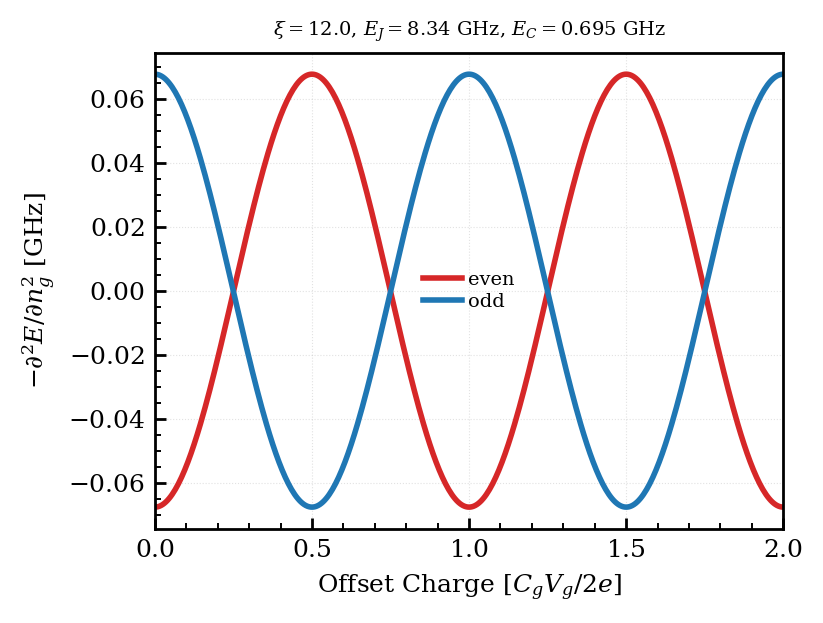

In [4]:
qpd.plot_quantum_capacitance(ng)


(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': '$\\xi=12.0$, $E_J=8.34$ GHz, $E_C=0.695$ GHz'}, xlabel='Offset Charge [$C_g V_g / 2e$]', ylabel='$C_Q$ [fF]'>)

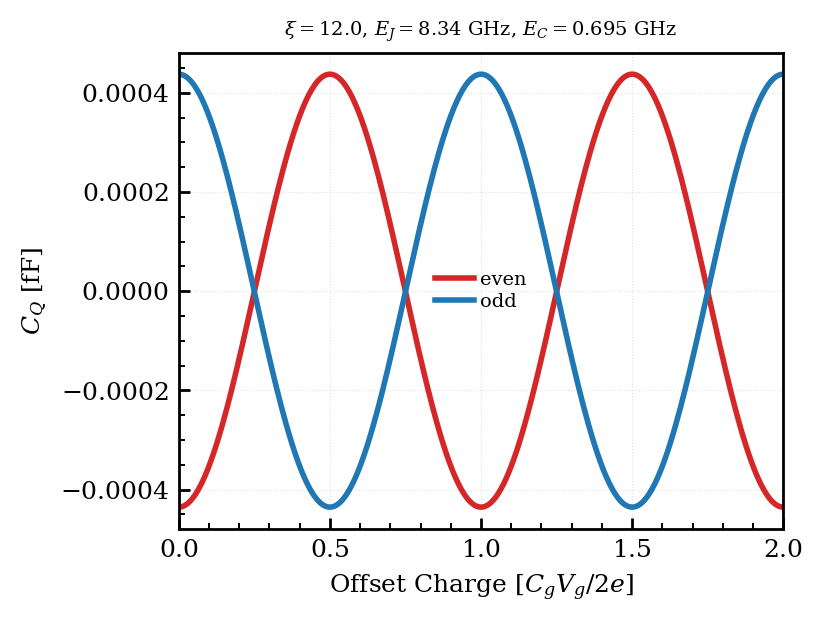

In [5]:
qpd.plot_quantum_capacitance(ng, c_g_f=1e-15)


## How the shape depends on $E_J/E_C$

Sweeping the ratio shows the two intuitive limits:

- $E_J/E_C \to \infty$ (deep transmon): charge dispersion is
  exponentially suppressed, so $C_Q(n_g)$ flattens.
- $E_J/E_C \to 0$ (Cooper-pair box): charge dispersion is large
  and $C_Q$ develops sharp peaks at $n_g = 0.5$ (even) and
  $n_g = 0$ (odd).


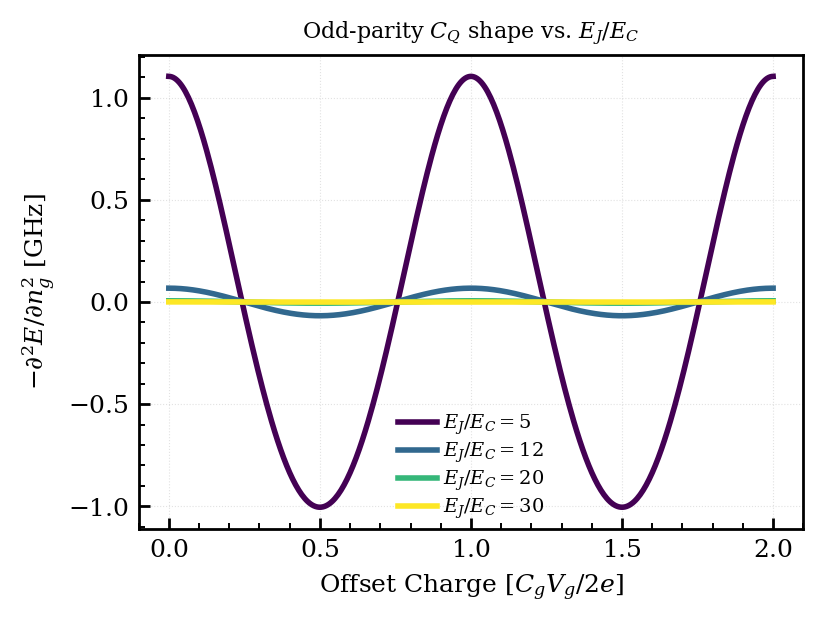

In [6]:
ratios = [5, 12, 20, 30]
e_c_hz = 0.695e9
with plt.style.context(QPD._style_path):
    fig, ax = plt.subplots(figsize=(4, 3))
    cmap = plt.colormaps.get_cmap('viridis')
    for k, r in enumerate(ratios):
        q = QPD(e_j_hz=r * e_c_hz, e_c_hz=e_c_hz)
        _, cq_o = q.compute_quantum_capacitance(ng)
        ax.plot(ng, cq_o / 1e9, color=cmap(k / (len(ratios) - 1)),
                linewidth=2, label=f'$E_J/E_C={r}$')
    ax.set_xlabel(r'Offset Charge [$C_g V_g / 2e$]')
    ax.set_ylabel(r'$-\partial^2 E / \partial n_g^2$ [GHz]')
    ax.set_title('Odd-parity $C_Q$ shape vs. $E_J/E_C$', fontsize=8)
    ax.legend(fontsize=7)
    ax.minorticks_on(); ax.grid(alpha=0.3)
    plt.show()


Just to highlight the shape difference, we do another one with normalized $C_Q$.

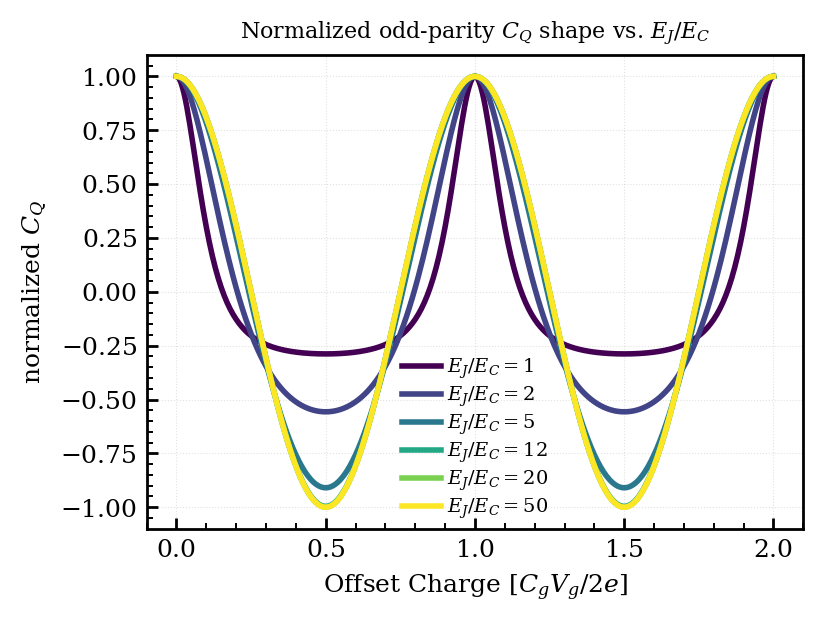

In [7]:
ratios = [1, 2, 5, 12, 20, 50]
e_c_hz = 0.695e9
with plt.style.context(QPD._style_path):
    fig, ax = plt.subplots(figsize=(4, 3))
    cmap = plt.colormaps.get_cmap('viridis')
    for k, r in enumerate(ratios):
        q = QPD(e_j_hz=r * e_c_hz, e_c_hz=e_c_hz)
        _, cq_o = q.compute_quantum_capacitance(ng)
        cq_norm = cq_o / np.max(np.abs(cq_o))  # Normalize y to max abs value to highlight shape
        ax.plot(ng, cq_norm, color=cmap(k / (len(ratios) - 1)),
                linewidth=2, label=f'$E_J/E_C={r}$')
    ax.set_xlabel(r'Offset Charge [$C_g V_g / 2e$]')
    ax.set_ylabel(r'normalized $C_Q$')
    ax.set_title('Normalized odd-parity $C_Q$ shape vs. $E_J/E_C$', fontsize=8)
    ax.legend(fontsize=7)
    ax.minorticks_on(); ax.grid(alpha=0.3)
    plt.show()


# Fitting a measured trace

In practice we measure $C_Q$ as a function of $n_g$ — typically via
a phase-shift readout (see `readout_inversion.ipynb`) — and want
to extract the device parameters that produced it. Following
issue #4 we fit four quantities:

- $E_J$, $E_C$ — the qubit energies (the asymptotic Eq. 5 in
  arXiv:0902.4194 is *not* used; we fit the numerical curve);
- $n_{g,0}$ — a charge offset, in case the measurement axis is not
  perfectly centred;
- `scale` — an overall amplitude that absorbs any unknown
  prefactor (so you don't need to know $C_g$ to fit the shape).

Below we generate a synthetic measurement, then run the fit.


In [8]:
ej_true, ec_true, ng0_true = 8.335e9, 0.695e9, 0.05
truth = QPD(e_j_hz=ej_true, e_c_hz=ec_true)

# Use a fine 1-period grid for the fit. The numerical 2nd
# derivative inside the fitter is sensitive to dn, so a denser
# grid keeps the chi^2 valley well-resolved. The visualisation
# grid `ng' (covering 2 periods, used above) is independent.
ng_fit = np.linspace(0, 1, 401)
_, cq_truth = truth.compute_quantum_capacitance(ng_fit - ng0_true)

rng = np.random.default_rng(0)
# 0.05 % per-point noise. The chi^2 valley along the (E_J, E_C)
# weak-shape direction is shallow; with much more noise the
# individual E_J / E_C values can drift by tens of percent even
# while the ratio stays tight.
noise = rng.normal(0, 5e-4 * np.max(np.abs(cq_truth)),
                   size=ng_fit.size)
cq_meas = cq_truth + noise


Start the fit from a *deliberately wrong* initial guess so we can
see the optimiser do real work. Because the synthetic data is in
intrinsic units (Hz), we know the true `scale` is 1 — fixing it
with `fit_scale=False` breaks the (E_C, scale) shape/amplitude
degeneracy and lets the fit pin $E_J$ and $E_C$ tightly.


In [9]:
guess = QPD(e_j_hz=1.1 * ej_true, e_c_hz=0.9 * ec_true)
fit = guess.fit_quantum_capacitance(
    ng_fit, cq_meas, parity='odd', fit_scale=False, fixed_scale=1.0,
)

# Profile-likelihood 1σ interval on the ratio.
# With fit_scale=False the valley is narrow, so a tight scan is enough.
prof = guess.profile_ratio_likelihood(
    ng_fit, cq_meas, fit, n_ratio=11, span_factor=1.05,
    charge_cutoff=10,
)
r_lo, r_hi = prof['sigma_levels']['1sigma']
r_best = prof['ratio_best']

# Tabulate results. Ratio error is asymmetric (profile-likelihood);
# everything else uses HESSE 1σ.
import pandas as pd
true_vals = {
    'e_j_hz': ej_true, 'e_c_hz': ec_true, 'n_g0': ng0_true,
    'ej_ec_ratio': ej_true / ec_true, 'scale': 1.0,
}
rows = []
for key in ('e_j_hz', 'e_c_hz', 'n_g0', 'ej_ec_ratio', 'scale'):
    if key == 'ej_ec_ratio':
        val = r_best
        plus = (r_hi - r_best) if r_hi is not None else None
        minus = (r_best - r_lo) if r_lo is not None else None
        err_str = (f'+{plus:.3g}/-{minus:.3g}'
                   if plus is not None and minus is not None else '')
    else:
        val = fit.get(key)
        err = fit.get('errors', {}).get(key)
        err_str = f'{err:.2g}' if err is not None else ''
    true = true_vals.get(key)
    err_pct = (abs(val - true) / abs(true) * 100.0
               if (true and abs(true) > 0) else None)
    rows.append({
        'name': key,
        'fitted': f'{val:.5g}' if val is not None else '',
        'error': err_str,
        'error [%]': f'{err_pct:.2f}' if err_pct is not None else '',
        'true': f'{true:.5g}' if true is not None else '',
    })
df = pd.DataFrame(rows, columns=['name', 'fitted', 'error', 'error [%]', 'true'])
print(df.to_string(index=False))


       name     fitted         error error [%]      true
     e_j_hz 8.2645e+09       1.6e+07      0.85 8.335e+09
     e_c_hz 6.9028e+08       1.1e+06      0.68  6.95e+08
       n_g0   0.050006       8.2e-05      0.01      0.05
ej_ec_ratio     11.973 +0.599/-0.532      0.17    11.993
      scale          1             0      0.00         1


(<Figure size 800x800 with 2 Axes>,
 (<Axes: title={'center': '$E_J=(8.264\\pm0.016)$ GHz, $E_C=(0.6903\\pm0.0011)$ GHz'}, ylabel='$C_Q$ [Hz]'>,
  <Axes: xlabel='Offset Charge [$C_g V_g / 2e$]', ylabel='residual [Hz]'>))

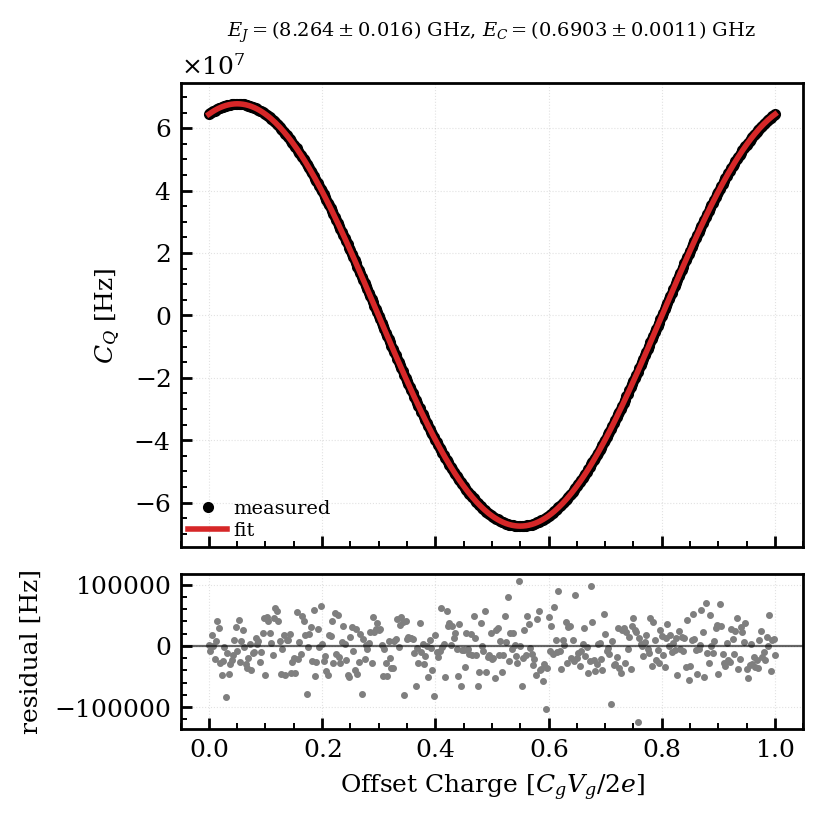

In [10]:
qpd.plot_capacitance_fit(ng_fit, cq_meas, fit, ratio_profile=prof)


## A note on noise sensitivity

The C_Q(n_g) curve in the QPD/transmon regime is nearly a pure
cosine — its *shape* depends only weakly on E_J/E_C, and the
absolute amplitude carries most of the information about the
energies. As a result the chi² valley in (E_J, E_C) space is
extremely shallow: with realistic 1 % noise the fit's individual
E_J and E_C values can drift by ~10 % along this valley while
the chi² stays at the noise floor. The **ratio** E_J/E_C, the
n_g offset, and the product `scale · E_C` remain well-determined.
If you need absolute energies in this regime, supplement the
C_Q fit with an independent measurement (e.g. anharmonicity
α ≈ -E_C from spectroscopy) to break the valley degeneracy.


## Axis units the fitter expects

Before fitting real data, it's worth being explicit about which
axis the fitter calibrates for you and which one you must
calibrate yourself.

**`cq_meas` (y-axis) — truly arbitrary unit.** The `scale`
parameter absorbs any multiplicative prefactor that relates your
y-axis to the intrinsic $-\partial^2 E/\partial n_g^2$ in Hz. You
can pass Farads, fF, a raw $\Delta f_r$ in Hz, or even
uncalibrated ADC counts — with `fit_scale=True` the shape fit is
invariant under any constant rescaling of `cq_meas`.

**`ng_fit` (x-axis) — NOT arbitrary.** The Hamiltonian model is
hard-coded to be periodic in $n_g$ with period 1 (one Cooper pair
$= 2e$). The fitter cannot learn an x-axis rescaling from the
model itself. If you hand it raw gate voltage where one Coulomb
period spans, say, 80 mV, it will try to fit a period-1 function
to a period-0.08 trace and either diverge or land on a garbage
basin.

So you do need to identify the period in your data once, from
the data itself:

1. Look at the $C_Q$ vs $V_g$ trace and measure the gate-voltage
   spacing $\Delta V_g$ between two equivalent features (peak-to-
   peak, or zero-crossing-to-zero-crossing of one full
   oscillation).
2. Define $n_g = (V_g - V_{g,0})/\Delta V_g$. By construction one
   period is now 1.
3. $C_g = 2e/\Delta V_g$ falls out as a byproduct if you want it,
   but you never have to pass it to the fitter.

You don't need to know *how many* periods are in the scan — the
fit handles any range — and you don't need $C_g$ as a physical
input. The x-axis period normalization is the one piece of
calibration the fitter cannot infer for you.


## When the absolute amplitude is unknown

If your measurement is in Farads but $C_g$ is uncertain, leave
`fit_scale=True` (the default). The fitter will absorb any unknown
prefactor into `scale`. The **shape** parameters $E_J/E_C$ and
$n_{g,0}$ remain identifiable; the absolute split between $E_C$
and `scale` becomes degenerate, so report the ratio rather than
the individual energies in that mode.


In [11]:
fit_loose = guess.fit_quantum_capacitance(
    ng_fit, cq_meas, parity='odd', fit_scale=True,
)
prof_loose = guess.profile_ratio_likelihood(
    ng_fit, cq_meas, fit_loose, n_ratio=15, span_factor=1.5,
    charge_cutoff=10,
)


(<Figure size 800x800 with 2 Axes>,
 (<Axes: title={'center': '$E_J/E_C=12.10^{+0.54}_{-0.66}$'}, ylabel='$C_Q$ [Hz]'>,
  <Axes: xlabel='Offset Charge [$C_g V_g / 2e$]', ylabel='residual [Hz]'>))

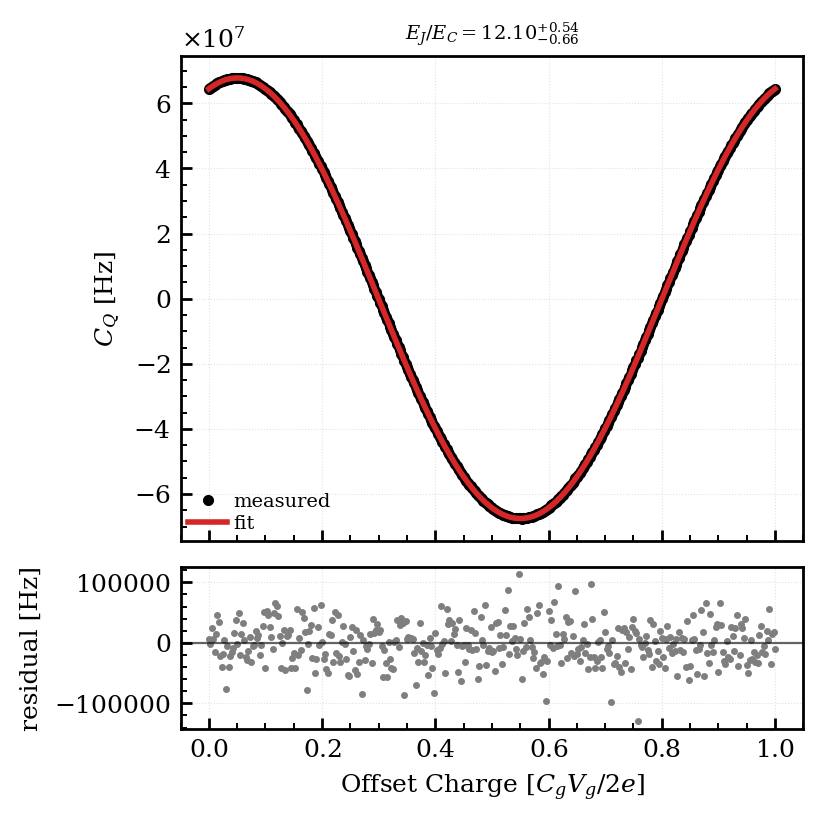

In [12]:
qpd.plot_capacitance_fit(ng_fit, cq_meas, fit_loose,
                         ratio_profile=prof_loose)


In [13]:
r_best_l = prof_loose['ratio_best']
lo_l, hi_l = prof_loose['sigma_levels']['1sigma']
print('Free-scale fit:')
print(f'  E_J/E_C  = {r_best_l:.3f} '
      f'+{(hi_l-r_best_l):.3f}/-{(r_best_l-lo_l):.3f}  '
      f'(truth {ej_true/ec_true:.3f})  [profile 1\u03c3]')
print(f'  n_g0     = {fit_loose["n_g0"]:+.4f}  (truth {ng0_true:+.4f})')
print(f'  scale    = {fit_loose["scale"]:.4g}')
print(f'  RMS resid (relative) = '
      f'{np.sqrt(np.mean(fit_loose["residuals"]**2)) / np.max(np.abs(cq_meas)):.3%}')


Free-scale fit:
  E_J/E_C  = 12.101 +0.539/-0.657  (truth 11.993)  [profile 1σ]
  n_g0     = +0.0500  (truth +0.0500)
  scale    = 1.651
  RMS resid (relative) = 0.050%


In short:

- Use `fit_scale=False, fixed_scale=...` whenever the
  data has been pre-converted to a known absolute convention.
- Use `fit_scale=True` (default) when only the trace shape is
  trustworthy; rely on `ej_ec_ratio` and `n_g0` from the result.


## Handling an unknown DC baseline

Real readouts almost always have an uncalibrated DC offset on
the C_Q axis — a constant shift that has nothing to do with the
qubit. The default fit absorbs this into `scale` *badly*: the
best-fit curve is biased and the residuals stop being mean-zero.
Passing `fit_baseline=True` adds an additive parameter
`baseline` so the model becomes

$$
\texttt{cq\_meas} \;\approx\; \texttt{scale}\cdot
f_\mathrm{intrinsic}(n_g-n_{g,0};\,E_J,E_C) \;+\; \texttt{baseline}.
$$

The baseline itself is recovered cleanly. The caveat: in the
deep-transmon limit ($E_J/E_C \gtrsim 10$) $f_\mathrm{intrinsic}$ is
nearly a pure cosine, so its DC component is correlated with
`scale × charge-dispersion(E_J, E_C)`. Fitting four free
parameters (E_J, E_C, scale, baseline) on top of a near-sinusoid
lets the (E_J, E_C) ratio drift along the shallow valley more
than the baseline-fixed fit above. If you have an independent
baseline estimate (e.g. from a far-detuned reference
measurement), prefer `fit_baseline=False, fixed_baseline=...`.


In [14]:
# Mimic an uncalibrated readout baseline by adding a DC offset.
y0_true = 0.10 * np.max(np.abs(cq_truth))  # 10% of peak
cq_meas_off = cq_meas + y0_true

fit_bl = guess.fit_quantum_capacitance(
    ng_fit, cq_meas_off, parity='odd',
    fit_scale=True, fit_baseline=True,
)
prof_bl = guess.profile_ratio_likelihood(
    ng_fit, cq_meas_off, fit_bl, n_ratio=15, span_factor=2.0,
    charge_cutoff=10,
)

r_b = prof_bl['ratio_best']
lo_b, hi_b = prof_bl['sigma_levels']['1sigma']
plus = (hi_b - r_b) if hi_b is not None else float('nan')
minus = (r_b - lo_b) if lo_b is not None else float('nan')
print('Free-scale + free-baseline fit:')
print(f'  E_J/E_C  = {r_b:.3f} +{plus:.3f}/-{minus:.3f}  '
      f'(truth {ej_true/ec_true:.3f})  [profile 1\u03c3]')
print(f'  n_g0     = {fit_bl["n_g0"]:+.4f}  (truth {ng0_true:+.4f})')
print(f'  scale    = {fit_bl["scale"]:.4g}')
print(f'  baseline = {fit_bl["baseline"]:+.4g}  (truth {y0_true:+.4g})')


Free-scale + free-baseline fit:
  E_J/E_C  = 12.338 +0.345/-0.551  (truth 11.993)  [profile 1σ]
  n_g0     = +0.0500  (truth +0.0500)
  scale    = 2.739
  baseline = +6.779e+06  (truth +6.78e+06)


(<Figure size 800x800 with 2 Axes>,
 (<Axes: title={'center': '$E_J/E_C=12.34^{+0.35}_{-0.55}$'}, ylabel='$C_Q$ [Hz]'>,
  <Axes: xlabel='Offset Charge [$C_g V_g / 2e$]', ylabel='residual [Hz]'>))

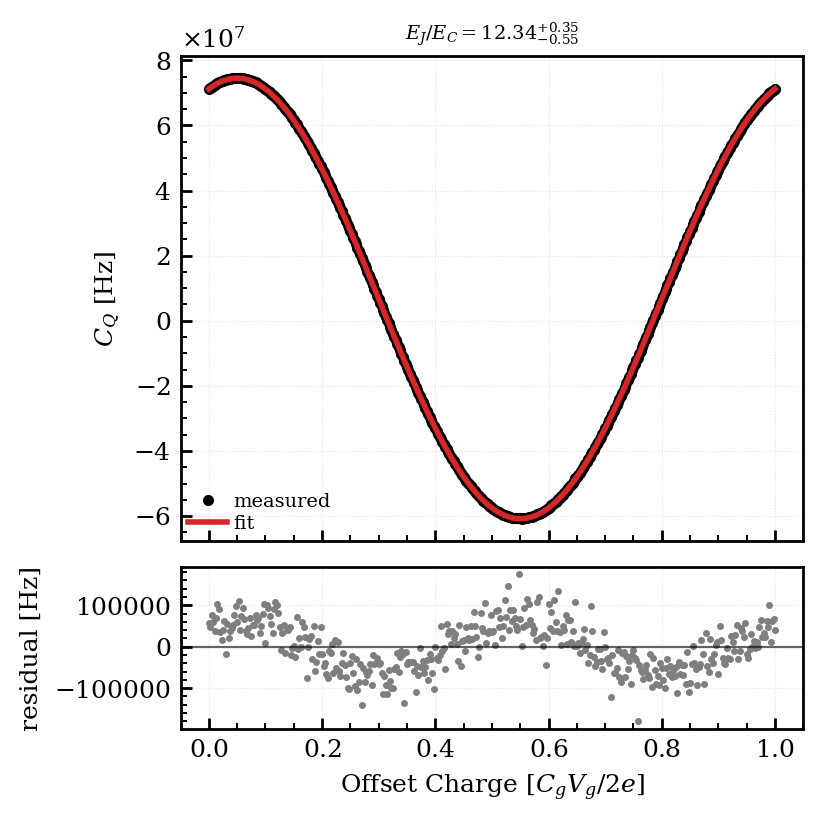

In [15]:
qpd.plot_capacitance_fit(ng_fit, cq_meas_off, fit_bl,
                         ratio_profile=prof_bl)


## Visualising the chi² landscape

The shallow-valley caveat above is easier to *see* than to argue
about. `plot_likelihood_landscape` evaluates chi² on an (E_J, E_C)
grid around the fit point (with n_g0 and scale held at their
fitted values) and overlays the 1σ / 2σ / 3σ joint-coverage
contours plus the constant-ratio line through the fit. A long
narrow valley along the constant-ratio line means the ratio is
well-determined but the individual energies are degenerate; a
round basin means both are tight.


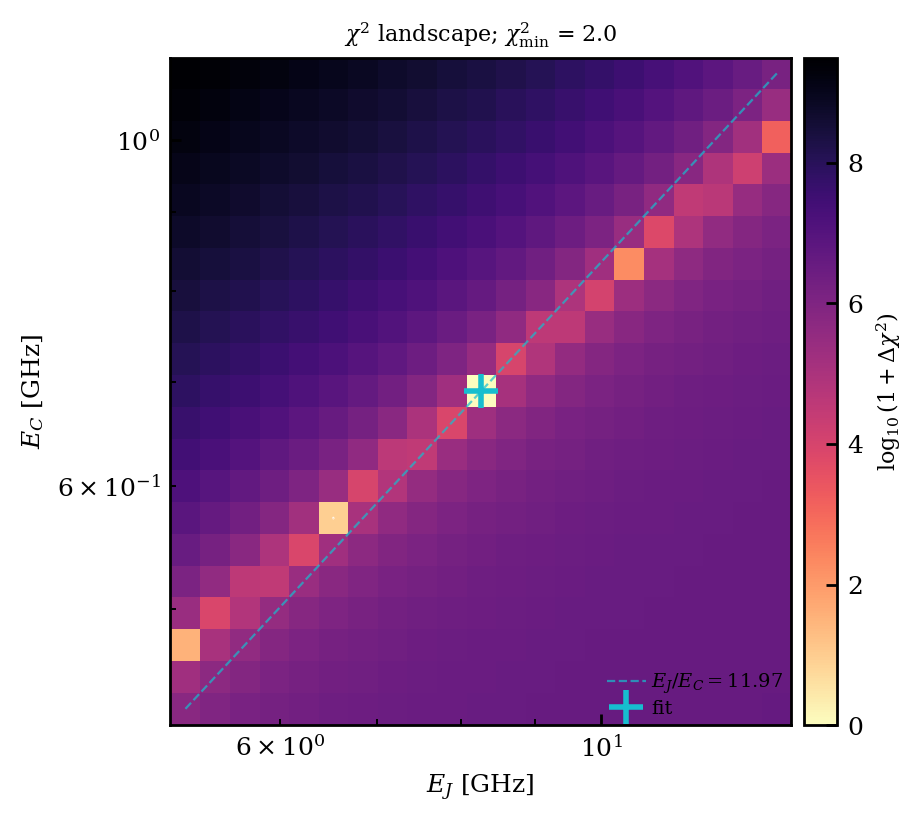

In [16]:
fig, ax = qpd.plot_likelihood_landscape(
    ng_fit, cq_meas, fit, parity='odd',
    n_grid=21, span_factor=1.6,
)


## Profile-likelihood error on $E_J/E_C$

The HESSE uncertainty on `ej_ec_ratio` is the local curvature
of the chi² surface at the minimum — it assumes the surface is
a paraboloid and only measures the second derivative. In the
deep-transmon limit the chi² valley along the ratio direction
is long, shallow, and curved, so HESSE dramatically
underestimates the true ratio uncertainty.

`profile_ratio_likelihood` is the 1D gold standard: at each
fixed ratio $r$ it refits $(E_C, n_{g,0}, \mathrm{scale},
\mathrm{baseline})$ with the constraint $E_J = r\cdot E_C$,
records the minimized chi², and reports the intervals where
$\Delta\chi^2 \le 1, 4, 9$ (the two-sided $1\sigma$, $2\sigma$,
$3\sigma$ confidence regions for one parameter of interest).
These intervals are the asymmetric error bars we used above on
each `E_J/E_C` printout — here we visualise the $\Delta\chi^2$
curve for the free-scale fit to make the valley shape concrete.


In [17]:
print(f'HESSE  : ratio = {fit_loose["ej_ec_ratio"]:.3f} '
      f'\u00b1 {fit_loose["errors"]["ej_ec_ratio"]:.3f}')
lo, hi = prof_loose['sigma_levels']['1sigma']
rb = prof_loose['ratio_best']
print(f'Profile: ratio = {rb:.3f} '
      f'+{(hi-rb):.3f}/-{(rb-lo):.3f}  [1\u03c3]')
print(f'         2\u03c3 = {prof_loose["sigma_levels"]["2sigma"]}')
print(f'         3\u03c3 = {prof_loose["sigma_levels"]["3sigma"]}')


HESSE  : ratio = 12.101 ± 0.019
Profile: ratio = 12.101 +0.539/-0.657  [1σ]
         2σ = (11.06955152257631, 13.666588676441496)
         3σ = (10.66230182905556, 15.247052987002569)


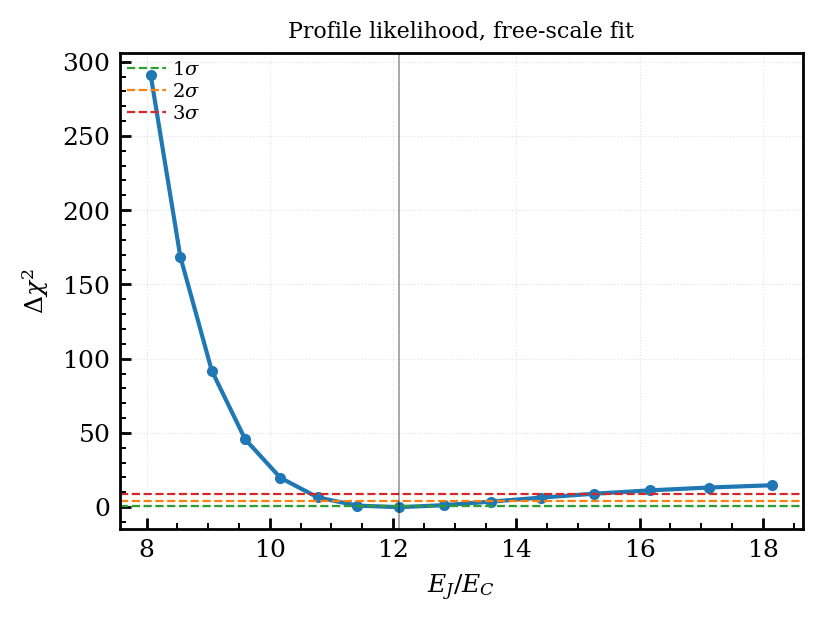

In [18]:
with plt.style.context(QPD._style_path):
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.plot(prof_loose['ratio_grid'], prof_loose['delta_chi2'],
            'o-', color='tab:blue', linewidth=1.5)
    for level, label, col in [(1.0, r'$1\sigma$', 'tab:green'),
                              (4.0, r'$2\sigma$', 'tab:orange'),
                              (9.0, r'$3\sigma$', 'tab:red')]:
        ax.axhline(level, color=col, linewidth=0.8,
                   linestyle='--', label=label)
    ax.axvline(prof_loose['ratio_best'], color='k',
               linewidth=0.6, alpha=0.4)
    ax.set_xlabel(r'$E_J/E_C$')
    ax.set_ylabel(r'$\Delta\chi^2$')
    ax.set_title('Profile likelihood, free-scale fit', fontsize=8)
    ax.legend(fontsize=7, loc='upper left')
    ax.minorticks_on(); ax.grid(alpha=0.3)
